# How to run with cloelib and CosmoPower-JAX

This notebook demonstrates how to use the CosmoPower-JAX emulators through the `cloelib` interface.

## Available emulators

| Class | Cosmology | Neutrinos | Spectrum |
|-------|-----------|-----------|---------|
| `CosmoPowerJAXLCDMPerturbations.Linear` | ΛCDM | 0, 1, 2, 3 | P(k) linear |
| `CosmoPowerJAXLCDMPerturbations.LinearCB` | ΛCDM | 0, 1, 2, 3 | P_cb(k) linear |
| `CosmoPowerJAXLCDMPerturbations.NonLinear` | ΛCDM | 0, 1, 2, 3 | P(k) nonlinear (HMcode2020 + log10TAGN) |
| `CosmoPowerJAXLCDMPerturbations.NonLinearCB` | ΛCDM | 0, 1, 2, 3 | P_cb(k) nonlinear |
| `CosmoPowerJAXwCDMPerturbations.Linear` | wCDM | 0, 1, 2, 3 | P(k) linear |
| `CosmoPowerJAXwCDMPerturbations.LinearCB` | wCDM | 0, 1, 2, 3 | P_cb(k) linear |
| `CosmoPowerJAXwCDMPerturbations.NonLinear` | wCDM | 0, 1, 2, 3 | P(k) nonlinear |
| `CosmoPowerJAXwCDMPerturbations.NonLinearCB` | wCDM | 0, 1, 2, 3 | P_cb(k) nonlinear |
| `CosmoPowerJAXw0waCDMPerturbations.Linear` | w0waCDM | 0, 1, 2, 3 | P(k) linear |
| `CosmoPowerJAXw0waCDMPerturbations.LinearCB` | w0waCDM | 0, 1, 2, 3 | P_cb(k) linear |
| `CosmoPowerJAXw0waCDMPerturbations.NonLinear` | w0waCDM | 0, 1, 2, 3 | P(k) nonlinear |
| `CosmoPowerJAXw0waCDMPerturbations.NonLinearCB` | w0waCDM | 0, 1, 2, 3 | P_cb(k) nonlinear |

All emulators also provide `sigma8`, `fsigma8`, `growth_factor(z, k)`, and `growth_rate()`.

**Parameter ranges (ΛCDM/w0wa):** ombh2 ∈ [0.001, 0.1], omch2 ∈ [0.05, 0.9], H0 ∈ [20, 100], ns ∈ [0.6, 1.3], lnAs ∈ [1.61, 5], z ∈ [0, 5], w0 ∈ [-3, -0.33], wa ∈ [-3, 3], mnu ∈ [0, 1] eV, logT_AGN  ∈ [7.3, 8.5]

---

**Notebook contents:**
1. Validation: linear P(k) vs CAMB
2. P(k) vs P_cb(k) — total matter vs CDM+baryons (the new `LinearCB`/`NonLinearCB` interface)
3. ΛCDM vs w0waCDM
4. Effect of neutrino mass (0, 1, 2, 3 species)
5. Linear vs Nonlinear P(k), baryonic feedback, and P_cb nonlinear
6. Growth factor D(z, k)
7. σ8(z) and fσ8(z)
8. Redshift evolution of P(k)
9. Timing: CosmoPower-JAX vs CAMB vs HMcode2020Emu

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cloelib.cosmology.camb_cosmology import (
    CAMBBackground,
    CAMBLinearPerturbations,
    CAMBNonLinearPerturbations,
)
from cloelib.cosmology.cosmopower_jax_cosmology import (
    CosmoPowerJAXLCDMPerturbations,
    CosmoPowerJAXw0waCDMPerturbations,
)

# Common settings
zs  = np.array([0.0, 0.5, 1.0, 2.0])
ks  = np.logspace(-4, 1, 300)  # Mpc^-1

# Fiducial cosmology (Planck 2018-like)
cosmo = dict(
    H0=67.0,
    Omega_b0=0.049,
    Omega_cdm0=0.270,
    Omega_k0=0.0,
    As=2.1e-9,
    ns=0.96,
    mnu=0.06,
    w0=-1.0,
    wa=0.0,
    gamma_MG=0.0,
    N_mnu=1,
)
print('Setup complete')

Setup complete


## 1. Validation: CosmoPowerJAX linear P(k) vs CAMB

We compare the linear matter power spectrum predicted by the CosmoPower-JAX emulator
against CAMB at several redshifts. We also show the relative difference.

Note: redshifts have been re-sorted (earliest first)


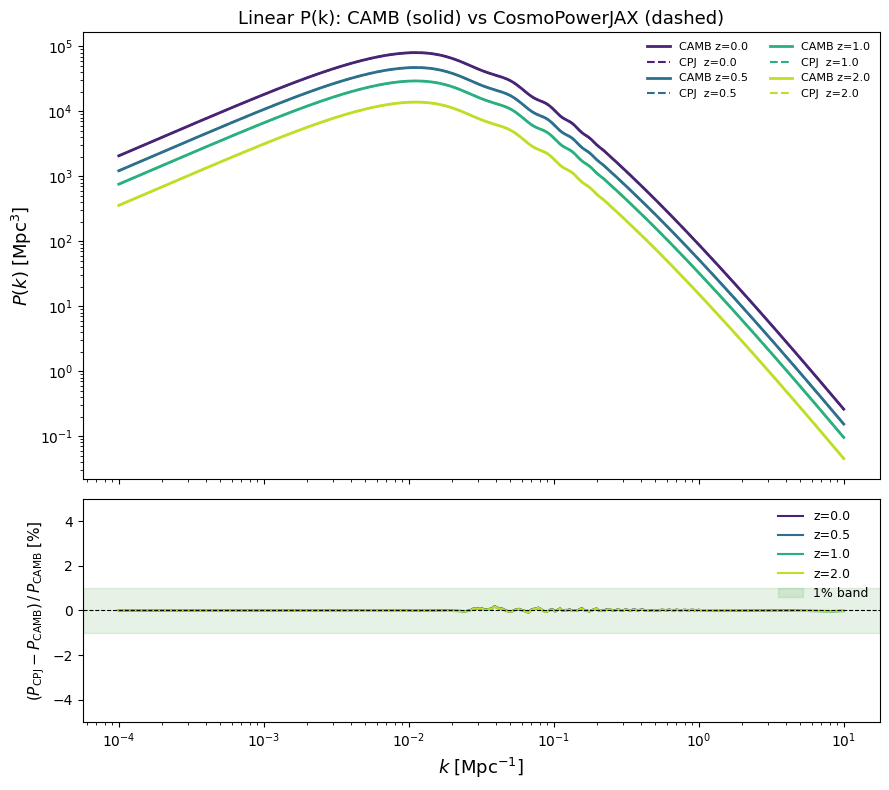

In [2]:
# CAMB
bg_camb = CAMBBackground(**cosmo)
lin_camb = CAMBLinearPerturbations(background=bg_camb, redshifts=zs)

# CosmoPowerJAX (LCDM, 1 massive neutrino)
bg_jax = CAMBBackground(**cosmo)
lin_jax = CosmoPowerJAXLCDMPerturbations.Linear(background=bg_jax, redshifts=zs)

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(zs)))

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

for i, (z, c) in enumerate(zip(zs, colors)):
    pk_camb = np.squeeze(lin_camb.matter_power_spectrum(z, ks))
    pk_jax  = np.squeeze(lin_jax.matter_power_spectrum(z, ks))
    axes[0].loglog(ks, pk_camb, color=c, lw=2,           label=f'CAMB z={z}')
    axes[0].loglog(ks, pk_jax,  color=c, lw=1.5, ls='--', label=f'CPJ  z={z}')
    axes[1].semilogx(ks, (pk_jax - pk_camb) / pk_camb * 100, color=c, label=f'z={z}')

axes[0].set_ylabel(r'$P(k)\;[\mathrm{Mpc}^3]$', fontsize=13)
axes[0].legend(fontsize=8, frameon=False, ncol=2)
axes[0].set_title('Linear P(k): CAMB (solid) vs CosmoPowerJAX (dashed)', fontsize=13)

axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].axhspan(-1, 1, alpha=0.1, color='green', label='1% band')
axes[1].set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$', fontsize=13)
axes[1].set_ylabel(r'$(P_\mathrm{CPJ} - P_\mathrm{CAMB})\,/\,P_\mathrm{CAMB}\;[\%]$', fontsize=11)
axes[1].legend(fontsize=9, frameon=False)
axes[1].set_ylim(-5, 5)

plt.tight_layout()
plt.show()

## 2. Total matter P(k) vs CDM+baryons P_cb(k)

With massive neutrinos the total matter power spectrum P(k) is suppressed on small scales
because neutrinos free-stream and do not cluster. P_cb(k) — the CDM+baryon spectrum —
is less suppressed and is often used as input to nonlinear models (HMcode, halofit).

**cloelib's P_cb interface.** Since the recent update, `cloelib` exposes the CDM+baryon
spectrum directly through the `LinearCB` and `NonLinearCB` inner classes, alongside the
total-matter `Linear` / `NonLinear` ones. They share the same `matter_power_spectrum(z, k)`
signature so they are drop-in compatible — only the returned spectrum changes (P_m vs P_cb).

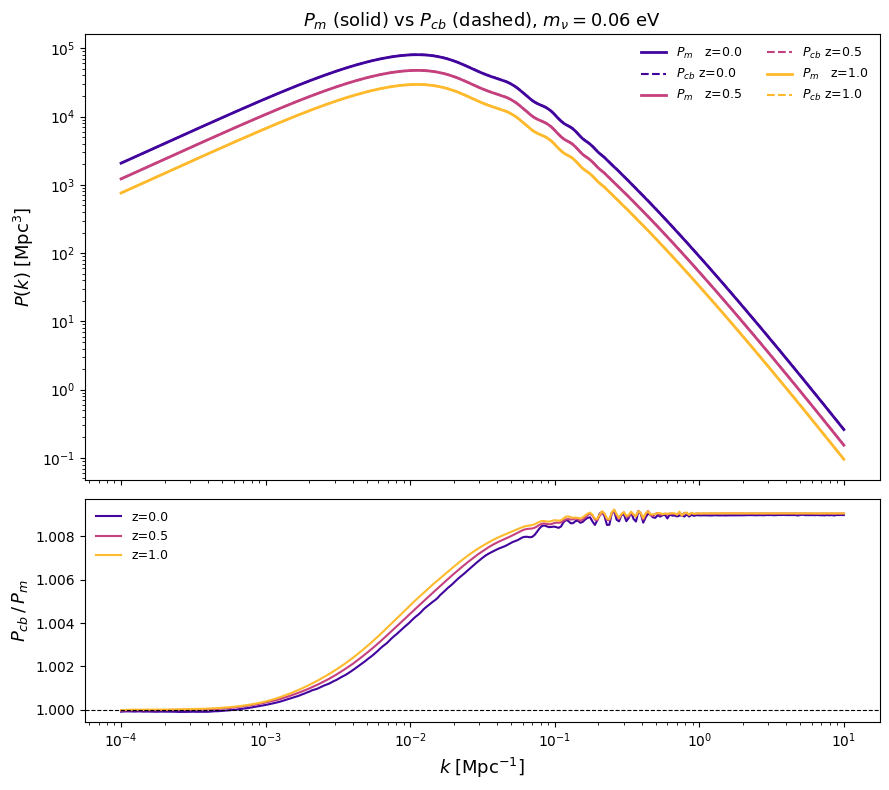

In [3]:
zs_cb = np.array([0.0, 0.5, 1.0])

lin_tot = CosmoPowerJAXLCDMPerturbations.Linear(background=bg_jax,   redshifts=zs_cb)
lin_cb  = CosmoPowerJAXLCDMPerturbations.LinearCB(background=bg_jax, redshifts=zs_cb)

colors_cb = plt.cm.plasma(np.linspace(0.1, 0.85, len(zs_cb)))

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

for z, c in zip(zs_cb, colors_cb):
    pk_tot = np.squeeze(lin_tot.matter_power_spectrum(z, ks))
    pk_cb  = np.squeeze(lin_cb.matter_power_spectrum(z, ks))
    axes[0].loglog(ks, pk_tot, color=c, lw=2,           label=rf'$P_m$   z={z}')
    axes[0].loglog(ks, pk_cb,  color=c, lw=1.5, ls='--', label=rf'$P_{{cb}}$ z={z}')
    axes[1].semilogx(ks, pk_cb / pk_tot, color=c, label=f'z={z}')

axes[0].set_ylabel(r'$P(k)\;[\mathrm{Mpc}^3]$', fontsize=13)
axes[0].legend(fontsize=9, frameon=False, ncol=2)
axes[0].set_title(rf'$P_m$ (solid) vs $P_{{cb}}$ (dashed), $m_\nu={cosmo["mnu"]}$ eV', fontsize=13)

axes[1].axhline(1, color='k', lw=0.8, ls='--')
axes[1].set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$', fontsize=13)
axes[1].set_ylabel(r'$P_{cb}\,/\,P_m$', fontsize=13)
axes[1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

## 3. ΛCDM vs w0waCDM

We compare the linear matter power spectrum for a ΛCDM cosmology (w=-1, wa=0)
against two dark energy models: w0waCDM with w0=-0.9 and w0=-0.7 (both wa=0).
The ratio shows the dark energy signature in the power spectrum.

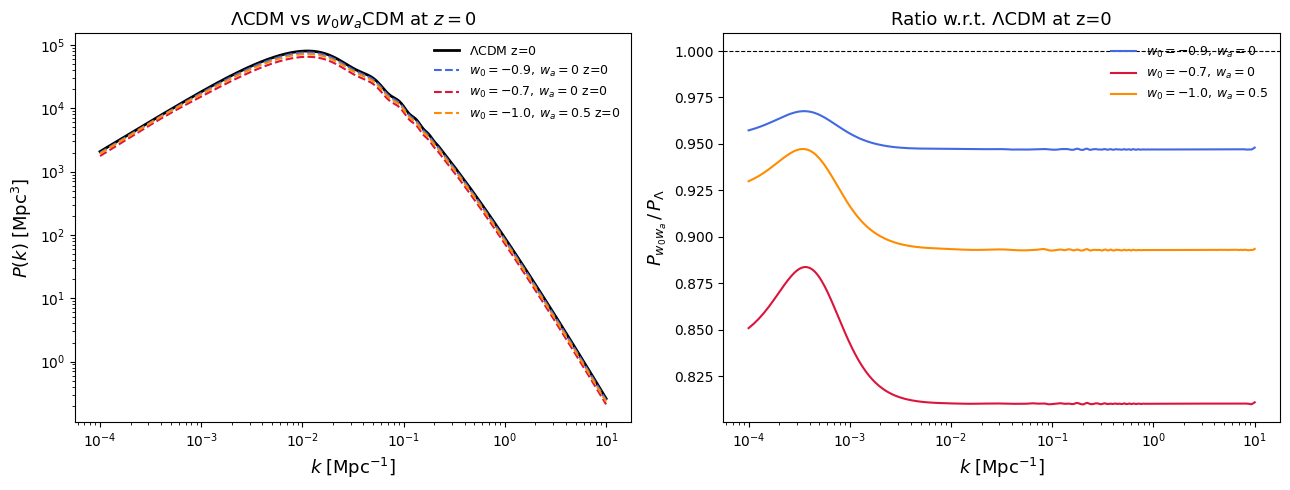

In [4]:
z_de = np.array([0.0, 1.0, 2.0])

# ΛCDM (w0=-1, wa=0)
cosmo_lcdm = {**cosmo, 'w0': -1.0, 'wa': 0.0}
bg_lcdm    = CAMBBackground(**cosmo_lcdm)
lin_lcdm   = CosmoPowerJAXLCDMPerturbations.Linear(background=bg_lcdm, redshifts=z_de)

# w0waCDM models
de_models = [
    {'w0': -0.9, 'wa':  0.0, 'label': r'$w_0=-0.9,\,w_a=0$',   'color': 'royalblue'},
    {'w0': -0.7, 'wa':  0.0, 'label': r'$w_0=-0.7,\,w_a=0$',   'color': 'crimson'},
    {'w0': -1.0, 'wa':  0.5, 'label': r'$w_0=-1.0,\,w_a=0.5$', 'color': 'darkorange'},
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

z_ref = 0.0
pk_lcdm_ref = np.squeeze(lin_lcdm.matter_power_spectrum(z_ref, ks))
axes[0].loglog(ks, pk_lcdm_ref, 'k-', lw=2, label=r'$\Lambda$CDM z=0')

for m in de_models:
    cosmo_de = {**cosmo, 'w0': m['w0'], 'wa': m['wa']}
    bg_de    = CAMBBackground(**cosmo_de)
    lin_de   = CosmoPowerJAXw0waCDMPerturbations.Linear(background=bg_de, redshifts=z_de)
    pk_de    = np.squeeze(lin_de.matter_power_spectrum(z_ref, ks))
    axes[0].loglog(ks, pk_de, color=m['color'], lw=1.5, ls='--', label=m['label'] + ' z=0')
    axes[1].semilogx(ks, pk_de / pk_lcdm_ref, color=m['color'], lw=1.5, label=m['label'])

axes[0].set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$', fontsize=13)
axes[0].set_ylabel(r'$P(k)\;[\mathrm{Mpc}^3]$', fontsize=13)
axes[0].set_title(r'$\Lambda$CDM vs $w_0w_a$CDM at $z=0$', fontsize=13)
axes[0].legend(fontsize=9, frameon=False)

axes[1].axhline(1, color='k', lw=0.8, ls='--')
axes[1].set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$', fontsize=13)
axes[1].set_ylabel(r'$P_{w_0w_a}\,/\,P_{\Lambda}$', fontsize=13)
axes[1].set_title('Ratio w.r.t. ΛCDM at z=0', fontsize=13)
axes[1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

## 4. Effect of neutrino mass

Massive neutrinos suppress the matter power spectrum on scales below their free-streaming
length. We compare four cases:
- **0 massive neutrinos** (massless limit)
- **1 massive neutrino** with total mass 0.06 eV
- **2 degenerate massive neutrinos** with total mass 0.2 eV
- **3 degenerate massive neutrinos** with total mass 0.3 eV

The suppression is approximately Δ P/P ≈ -8 Ω_ν / Ω_m on small scales.

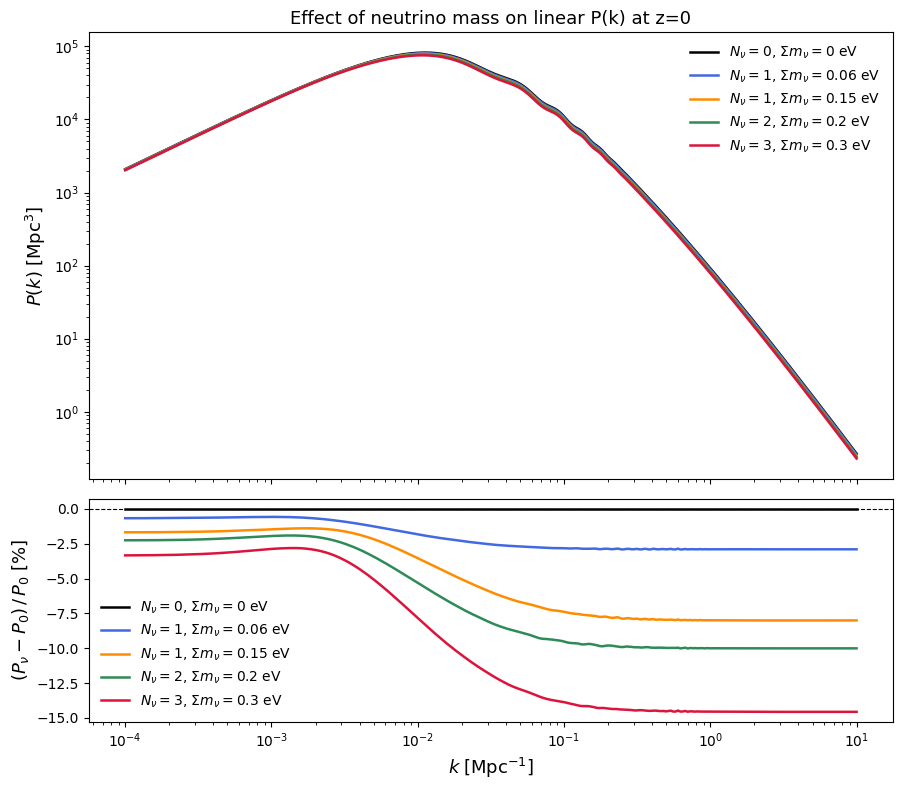

In [5]:
z_nu  = np.array([0.0, 1.0])

nu_models = [
    {'N_mnu': 0, 'mnu': 0.0,  'label': r'$N_\nu=0$, $\Sigma m_\nu=0$ eV',    'color': 'black'},
    {'N_mnu': 1, 'mnu': 0.06, 'label': r'$N_\nu=1$, $\Sigma m_\nu=0.06$ eV', 'color': 'royalblue'},
    {'N_mnu': 1, 'mnu': 0.15, 'label': r'$N_\nu=1$, $\Sigma m_\nu=0.15$ eV', 'color': 'darkorange'},
    {'N_mnu': 2, 'mnu': 0.2,  'label': r'$N_\nu=2$, $\Sigma m_\nu=0.2$ eV',  'color': 'seagreen'},
    {'N_mnu': 3, 'mnu': 0.3,  'label': r'$N_\nu=3$, $\Sigma m_\nu=0.3$ eV',  'color': 'crimson'},
]

# Reference: massless
cosmo_ref = {**cosmo, 'N_mnu': 0, 'mnu': 0.0}
bg_ref    = CAMBBackground(**cosmo_ref)
lin_ref   = CosmoPowerJAXLCDMPerturbations.Linear(background=bg_ref, redshifts=z_nu)
pk_ref    = np.squeeze(lin_ref.matter_power_spectrum(0.0, ks))

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

for m in nu_models:
    cosmo_nu = {**cosmo, 'N_mnu': m['N_mnu'], 'mnu': m['mnu']}
    bg_nu    = CAMBBackground(**cosmo_nu)
    lin_nu   = CosmoPowerJAXLCDMPerturbations.Linear(background=bg_nu, redshifts=z_nu)
    pk_nu    = np.squeeze(lin_nu.matter_power_spectrum(0.0, ks))
    axes[0].loglog(ks, pk_nu, color=m['color'], lw=1.8, label=m['label'])
    axes[1].semilogx(ks, (pk_nu - pk_ref) / pk_ref * 100, color=m['color'], lw=1.8, label=m['label'])

axes[0].set_ylabel(r'$P(k)\;[\mathrm{Mpc}^3]$', fontsize=13)
axes[0].set_title('Effect of neutrino mass on linear P(k) at z=0', fontsize=13)
axes[0].legend(fontsize=10, frameon=False)

axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$', fontsize=13)
axes[1].set_ylabel(r'$(P_\nu - P_0)\,/\,P_0\;[\%]$', fontsize=13)
axes[1].legend(fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

## 5. Linear vs Nonlinear P(k) and baryonic feedback

The nonlinear emulator (`NonLinear`) includes HMcode2020 corrections. We compare
linear vs nonlinear P(k) and show the effect of varying `log10TAGN` — the AGN feedback
temperature parameter — on the nonlinear suppression at small scales.

We also demonstrate the nonlinear P_cb interface (`NonLinearCB`) at a fixed `log10TAGN`,
showing the analogous CDM+baryon nonlinear spectrum that is the natural input for many
downstream calculations.

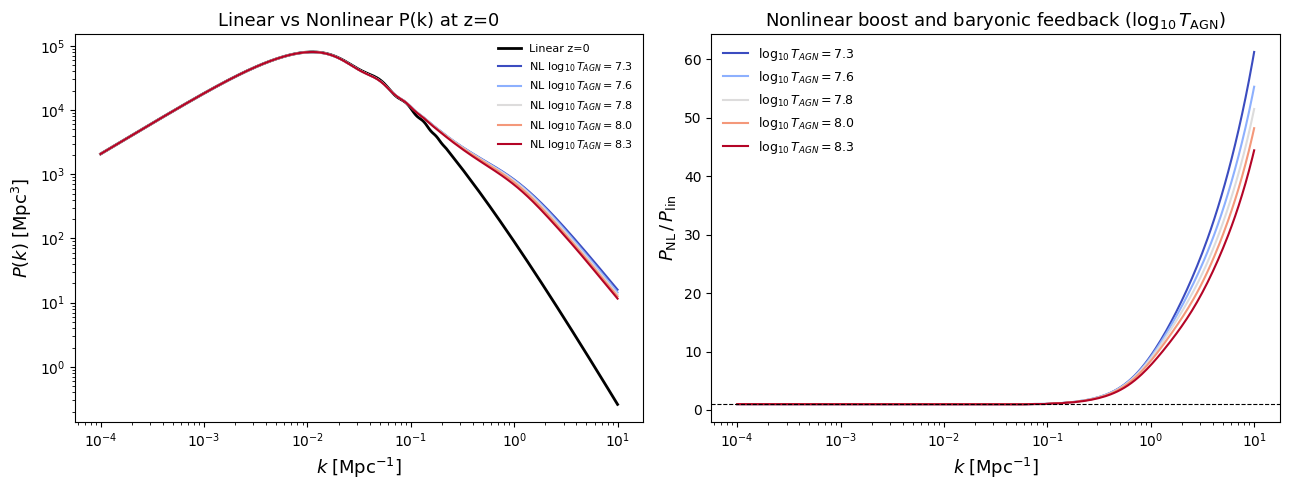

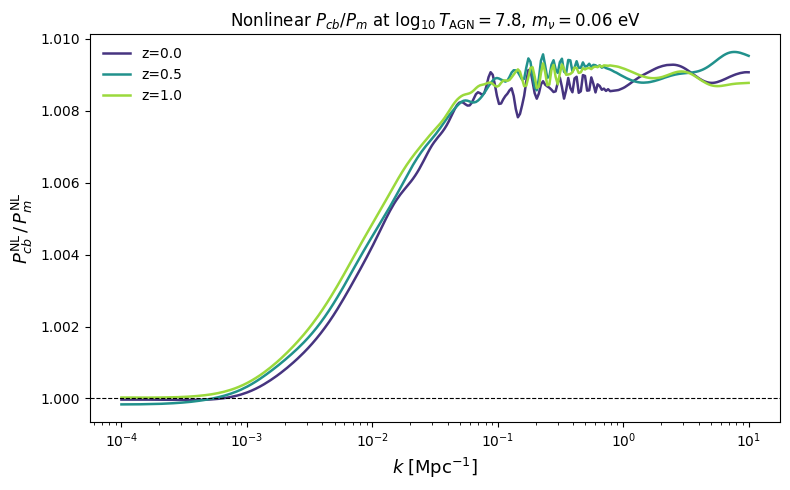

In [6]:
z_nl = np.array([0.0, 0.5, 1.0])

lin_nl  = CosmoPowerJAXLCDMPerturbations.Linear(background=bg_jax, redshifts=z_nl)

tagn_values = [7.3, 7.6, 7.8, 8.0, 8.3]
colors_tagn = plt.cm.coolwarm(np.linspace(0.0, 1.0, len(tagn_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pk_lin_z0 = np.squeeze(lin_nl.matter_power_spectrum(0.0, ks))
axes[0].loglog(ks, pk_lin_z0, 'k-', lw=2, label='Linear z=0')

for tagn, c in zip(tagn_values, colors_tagn):
    nl = CosmoPowerJAXLCDMPerturbations.NonLinear(
        background=bg_jax, redshifts=z_nl, log10TAGN=tagn, linearperturbations=lin_nl
    )
    pk_nl = np.squeeze(nl.matter_power_spectrum(0.0, ks))
    axes[0].loglog(ks, pk_nl, color=c, lw=1.5, label=rf'NL $\log_{{10}}T_{{AGN}}={tagn}$')
    axes[1].semilogx(ks, pk_nl / pk_lin_z0, color=c, lw=1.5, label=rf'$\log_{{10}}T_{{AGN}}={tagn}$')

axes[0].set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$', fontsize=13)
axes[0].set_ylabel(r'$P(k)\;[\mathrm{Mpc}^3]$', fontsize=13)
axes[0].set_title('Linear vs Nonlinear P(k) at z=0', fontsize=13)
axes[0].legend(fontsize=8, frameon=False)

axes[1].axhline(1, color='k', lw=0.8, ls='--')
axes[1].set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$', fontsize=13)
axes[1].set_ylabel(r'$P_\mathrm{NL}\,/\,P_\mathrm{lin}$', fontsize=13)
axes[1].set_title(r'Nonlinear boost and baryonic feedback ($\log_{10}T_\mathrm{AGN}$)', fontsize=13)
axes[1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

# --- Nonlinear total matter vs Nonlinear CDM+baryons (P_cb) ---
# Same matter_power_spectrum(z, k) interface, different inner class.
tagn_fixed = 7.8
lin_nl_cb = CosmoPowerJAXLCDMPerturbations.LinearCB(background=bg_jax, redshifts=z_nl)
nl_tot = CosmoPowerJAXLCDMPerturbations.NonLinear(
    background=bg_jax, redshifts=z_nl, log10TAGN=tagn_fixed, linearperturbations=lin_nl,
)
nl_cb = CosmoPowerJAXLCDMPerturbations.NonLinearCB(
    background=bg_jax, redshifts=z_nl, log10TAGN=tagn_fixed, linearperturbations=lin_nl_cb,
)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
colors_cb2 = plt.cm.viridis(np.linspace(0.15, 0.85, len(z_nl)))
for z, c in zip(z_nl, colors_cb2):
    pk_nl_tot = np.squeeze(nl_tot.matter_power_spectrum(z, ks))
    pk_nl_cb  = np.squeeze(nl_cb.matter_power_spectrum(z, ks))
    ax.semilogx(ks, pk_nl_cb / pk_nl_tot, color=c, lw=1.8, label=f'z={z}')

ax.axhline(1, color='k', lw=0.8, ls='--')
ax.set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$', fontsize=13)
ax.set_ylabel(r'$P^\mathrm{NL}_{cb}\,/\,P^\mathrm{NL}_m$', fontsize=13)
ax.set_title(rf'Nonlinear $P_{{cb}}/P_m$ at $\log_{{10}}T_\mathrm{{AGN}}={tagn_fixed}$, $m_\nu={cosmo["mnu"]}$ eV', fontsize=12)
ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.show()

## 6. Growth factor D(z, k)

The growth factor D(z, k) = sqrt(P(z,k) / P(0,k)) describes how structure grows over
time. With massive neutrinos the growth becomes scale-dependent — neutrinos suppress
growth on scales below their free-streaming length.

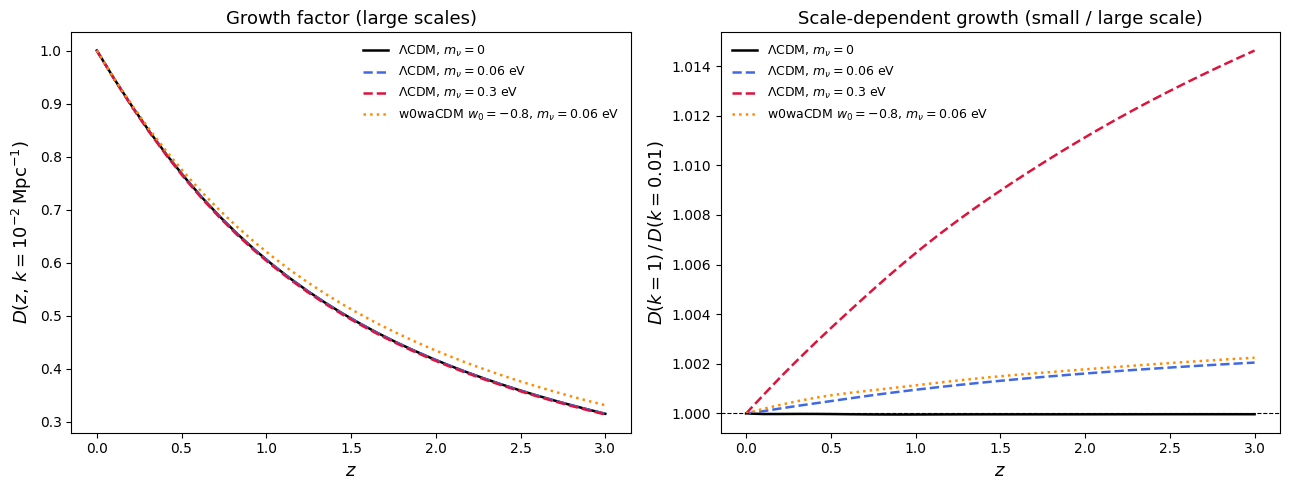

In [7]:
z_gf = np.linspace(0.0, 3.0, 30)

gf_models = [
    {'N_mnu': 0, 'mnu': 0.0,  'w0': -1.0, 'wa': 0.0, 'label': r'ΛCDM, $m_\nu=0$',          'color': 'black',      'ls': '-'},
    {'N_mnu': 1, 'mnu': 0.06, 'w0': -1.0, 'wa': 0.0, 'label': r'ΛCDM, $m_\nu=0.06$ eV',    'color': 'royalblue',  'ls': '--'},
    {'N_mnu': 1, 'mnu': 0.3,  'w0': -1.0, 'wa': 0.0, 'label': r'ΛCDM, $m_\nu=0.3$ eV',     'color': 'crimson',    'ls': '--'},
    {'N_mnu': 1, 'mnu': 0.06, 'w0': -0.8, 'wa': 0.0, 'label': r'w0waCDM $w_0=-0.8$, $m_\nu=0.06$ eV', 'color': 'darkorange', 'ls': ':'},
]

k_large = 1e-2   # large scale (k in Mpc^-1)
k_small = 1.0    # small scale

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for m in gf_models:
    cosmo_gf = {**cosmo, 'N_mnu': m['N_mnu'], 'mnu': m['mnu'], 'w0': m['w0'], 'wa': m['wa']}
    bg_gf    = CAMBBackground(**cosmo_gf)
    if m['w0'] == -1.0 and m['wa'] == 0.0:
        lin_gf = CosmoPowerJAXLCDMPerturbations.Linear(background=bg_gf, redshifts=z_gf)
    else:
        lin_gf = CosmoPowerJAXw0waCDMPerturbations.Linear(background=bg_gf, redshifts=z_gf)

    D_large = np.squeeze(lin_gf.growth_factor(z_gf, np.array([k_large])))
    D_small = np.squeeze(lin_gf.growth_factor(z_gf, np.array([k_small])))

    axes[0].plot(z_gf, D_large, color=m['color'], ls=m['ls'], lw=1.8, label=m['label'])
    axes[1].plot(z_gf, D_small / D_large, color=m['color'], ls=m['ls'], lw=1.8, label=m['label'])

axes[0].set_xlabel(r'$z$', fontsize=13)
axes[0].set_ylabel(r'$D(z,\,k=10^{-2}\,\mathrm{Mpc}^{-1})$', fontsize=13)
axes[0].set_title('Growth factor (large scales)', fontsize=13)
axes[0].legend(fontsize=9, frameon=False)

axes[1].axhline(1, color='k', lw=0.8, ls='--')
axes[1].set_xlabel(r'$z$', fontsize=13)
axes[1].set_ylabel(r'$D(k=1)\,/\,D(k=0.01)$', fontsize=13)
axes[1].set_title('Scale-dependent growth (small / large scale)', fontsize=13)
axes[1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

## 7. σ8(z) and fσ8(z)

σ8(z) measures the amplitude of matter fluctuations in 8 Mpc/h spheres.
fσ8(z) = f(z) · σ8(z) is the observable measured directly from redshift-space
distortions (RSDs) and is a key probe of gravity.

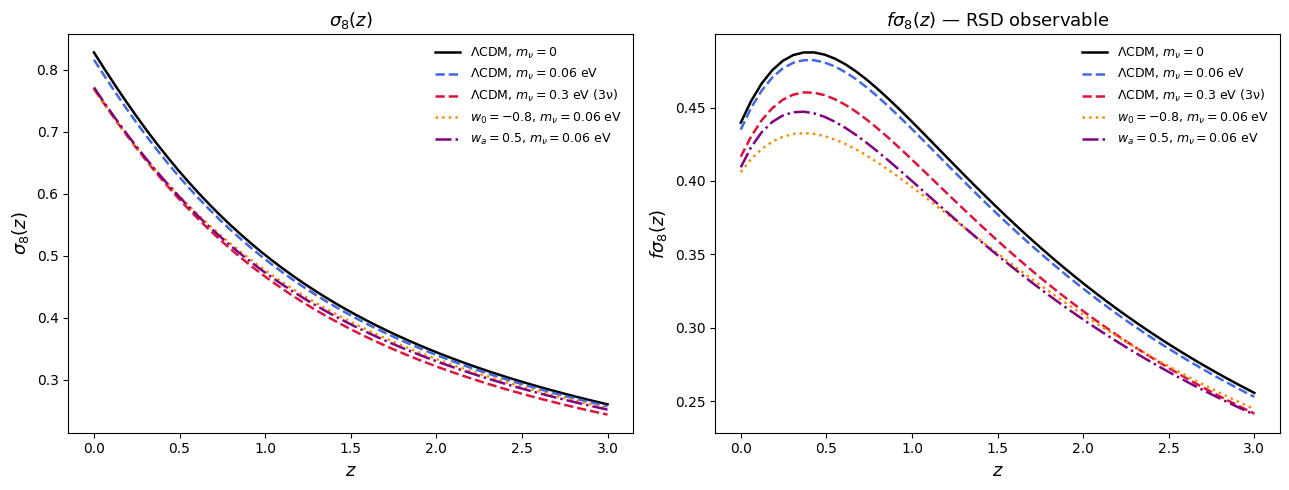

In [8]:
z_s8 = np.linspace(0.0, 3.0, 50)

s8_models = [
    {'N_mnu': 0, 'mnu': 0.0,  'w0': -1.0, 'wa':  0.0, 'label': r'ΛCDM, $m_\nu=0$',             'color': 'black',      'ls': '-'},
    {'N_mnu': 1, 'mnu': 0.06, 'w0': -1.0, 'wa':  0.0, 'label': r'ΛCDM, $m_\nu=0.06$ eV',       'color': 'royalblue',  'ls': '--'},
    {'N_mnu': 3, 'mnu': 0.3,  'w0': -1.0, 'wa':  0.0, 'label': r'ΛCDM, $m_\nu=0.3$ eV (3ν)',   'color': 'crimson',    'ls': '--'},
    {'N_mnu': 1, 'mnu': 0.06, 'w0': -0.8, 'wa':  0.0, 'label': r'$w_0=-0.8$, $m_\nu=0.06$ eV', 'color': 'darkorange', 'ls': ':'},
    {'N_mnu': 1, 'mnu': 0.06, 'w0': -1.0, 'wa':  0.5, 'label': r'$w_a=0.5$, $m_\nu=0.06$ eV',  'color': 'purple',     'ls': '-.'},
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for m in s8_models:
    cosmo_s8 = {**cosmo, 'N_mnu': m['N_mnu'], 'mnu': m['mnu'], 'w0': m['w0'], 'wa': m['wa']}
    bg_s8    = CAMBBackground(**cosmo_s8)
    if m['w0'] == -1.0 and m['wa'] == 0.0:
        lin_s8 = CosmoPowerJAXLCDMPerturbations.Linear(background=bg_s8, redshifts=z_s8)
    else:
        lin_s8 = CosmoPowerJAXw0waCDMPerturbations.Linear(background=bg_s8, redshifts=z_s8)

    axes[0].plot(z_s8, lin_s8.sigma8,   color=m['color'], ls=m['ls'], lw=1.8, label=m['label'])
    axes[1].plot(z_s8, lin_s8.fsigma8,  color=m['color'], ls=m['ls'], lw=1.8, label=m['label'])

axes[0].set_xlabel(r'$z$', fontsize=13)
axes[0].set_ylabel(r'$\sigma_8(z)$', fontsize=13)
axes[0].set_title(r'$\sigma_8(z)$', fontsize=13)
axes[0].legend(fontsize=9, frameon=False)

axes[1].set_xlabel(r'$z$', fontsize=13)
axes[1].set_ylabel(r'$f\sigma_8(z)$', fontsize=13)
axes[1].set_title(r'$f\sigma_8(z)$ — RSD observable', fontsize=13)
axes[1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

## 8. Redshift evolution of P(k)

Structure grows over time as gravitational collapse amplifies density perturbations.
Here we show P(k) at several redshifts from z=0 to z=3 to visualise this growth.

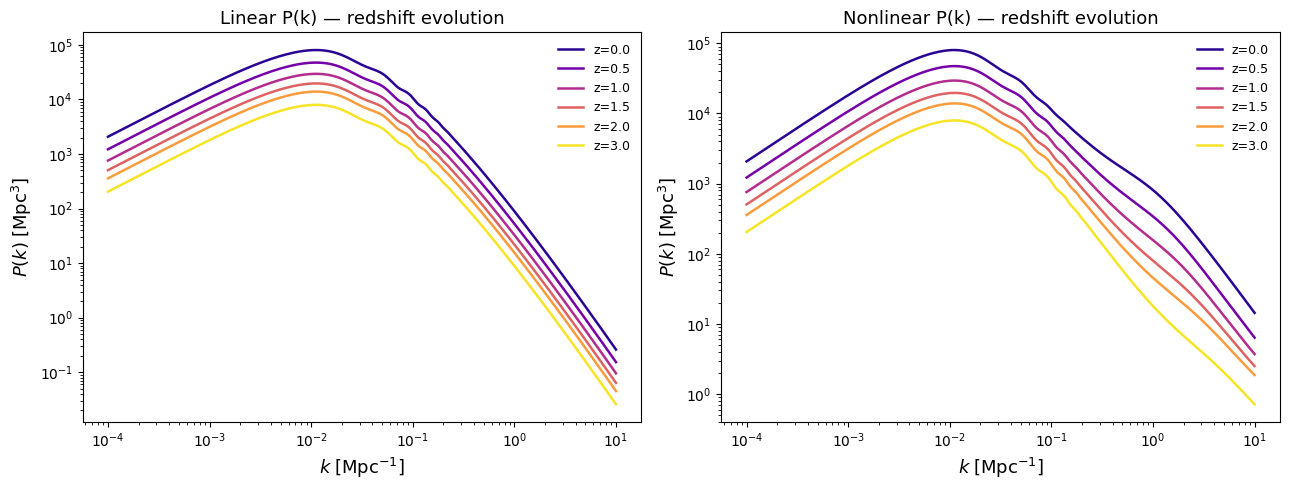

In [9]:
z_evol = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 3.0])
colors_evol = plt.cm.plasma(np.linspace(0.05, 0.95, len(z_evol)))

lin_evol = CosmoPowerJAXLCDMPerturbations.Linear(background=bg_jax, redshifts=z_evol)
nl_evol  = CosmoPowerJAXLCDMPerturbations.NonLinear(background=bg_jax, redshifts=z_evol, log10TAGN=7.6, linearperturbations=lin_evol)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for z, c in zip(z_evol, colors_evol):
    pk_l  = np.squeeze(lin_evol.matter_power_spectrum(z, ks))
    pk_nl = np.squeeze(nl_evol.matter_power_spectrum(z, ks))
    axes[0].loglog(ks, pk_l,  color=c, lw=1.8, label=f'z={z}')
    axes[1].loglog(ks, pk_nl, color=c, lw=1.8, label=f'z={z}')

for ax, title in zip(axes, ['Linear P(k)', 'Nonlinear P(k)']):
    ax.set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$', fontsize=13)
    ax.set_ylabel(r'$P(k)\;[\mathrm{Mpc}^3]$', fontsize=13)
    ax.set_title(title + ' — redshift evolution', fontsize=13)
    ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

## 9. Timing: CosmoPower-JAX vs CAMB vs HMcode2020Emu

We benchmark a single P(k) evaluation for the CosmoPower-JAX emulator, CAMB,
and the `HMcode2020Emu` emulator (also available through `cloelib`) to demonstrate
the speedup achieved by emulation relative to a full Boltzmann solve.

In [10]:
import timeit
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations

z_bench = np.array([0.0, 0.5, 1.0, 2.0])
N = 20

# Apples-to-apples: each call rebuilds the perturbations object at the fiducial cosmology and evaluates P(k) once. This is the workflow a likelihood/sampler performs every step.

# --- CAMB ---
def camb_call():
    bg = CAMBBackground(**cosmo)
    lp = CAMBLinearPerturbations(background=bg, redshifts=z_bench)
    lp.matter_power_spectrum(0.0, ks)

t_camb = timeit.timeit(camb_call, number=N) / N

# --- HMcode2020Emu (linear) ---
def hmemu_call():
    bg = CAMBBackground(**cosmo)
    lp = HMemuLinearPerturbations(background=bg, redshifts=z_bench)
    lp.matter_power_spectrum(0.0, ks)

t_hmemu = timeit.timeit(hmemu_call, number=N) / N

# --- CosmoPower-JAX (after JIT warm-up of the full construct+evaluate path) ---
def jax_call():
    bg = CAMBBackground(**cosmo)
    lp = CosmoPowerJAXLCDMPerturbations.Linear(background=bg, redshifts=z_bench)
    lp.matter_power_spectrum(0.0, ks)

jax_call()  # warm-up JIT
t_jax = timeit.timeit(jax_call, number=N) / N

print(f"CAMB           : {t_camb*1e3:.1f} ms  per call")
print(f"HMcode2020Emu  : {t_hmemu*1e3:.3f} ms  per call")
print(f"CosmoPower-JAX : {t_jax*1e3:.3f} ms  per call")
print(f"Speedup vs CAMB — HMcode2020Emu: {t_camb/t_hmemu:.0f}x, CosmoPower-JAX: {t_camb/t_jax:.0f}x")

/Users/ivan/Desktop/cloe2/HMcode2020Emu/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...


Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (